# When "Probably" Becomes "Definitely"
## Simulating the Cost of Probability Rounding

When a weather app says **60% chance of rain**, most people round up mentally: *"It's going to rain."*
When it says **35%**, they round down: *"It won't rain."*

This feels like common sense — it turns a messy number into a clear action. But rounding comes with a hidden, predictable cost.

This exercise simulates what happens when you treat probabilities as binary facts, and shows how the error rate follows directly from the math.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

## 1. Rounding up: "60% means it will rain"

The app shows **60% chance of rain**. Binary thinking rounds up: *"It's going to rain — I'll cancel the picnic."*

Simulate 1,000 days where the true rain probability is 60%.
How many of those days stay dry — making binary thinking wrong?

In [2]:
n_days = 1_000
p_rain = 0.60

outcomes = RNG.binomial(1, p_rain, n_days)
rainy = outcomes.sum()
dry   = n_days - rainy

print(f"Forecast: {p_rain:.0%} chance of rain")
print(f"Binary thinking predicts: rain every single day")
print()
print(f"Rainy days: {rainy:,}  ({rainy/n_days:.0%})")
print(f"Dry days:   {dry:,}  ({dry/n_days:.0%})  ← binary thinking is wrong here")

Forecast: 60% chance of rain
Binary thinking predicts: rain every single day

Rainy days: 603  (60%)
Dry days:   397  (40%)  ← binary thinking is wrong here


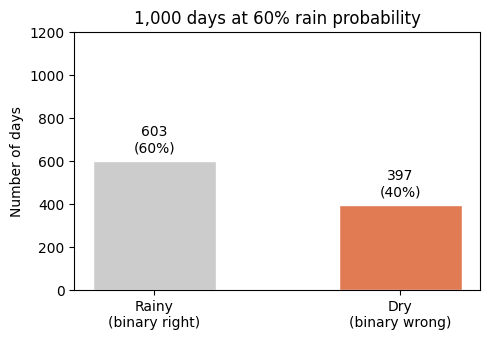

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Rainy\n(binary right)', 'Dry\n(binary wrong)'],
              [rainy, dry],
              color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/n_days:.0%})', padding=4, fontsize=10)
ax.set(title=f'1,000 days at {p_rain:.0%} rain probability',
       ylabel='Number of days', ylim=(0, 1_200))
plt.tight_layout()
plt.show()

Binary thinking is wrong **~40% of the time** — even though the forecast was 60%.
The error rate is exactly the complement of the probability: `1 - 0.60 = 0.40`.

This is not a flaw in the app. The app was right. The rounding was the mistake.

## 2. Rounding down: "35% means it won't rain"

Now the app shows **35% chance of rain**. Binary thinking rounds down: *"It probably won't rain — no need for an umbrella."*

Simulate 1,000 days at 35% true rain probability.
How many of those days actually rain — leaving you without an umbrella?

In [4]:
p_rain_low = 0.35

outcomes_low = RNG.binomial(1, p_rain_low, n_days)
rainy_low = outcomes_low.sum()
dry_low   = n_days - rainy_low

print(f"Forecast: {p_rain_low:.0%} chance of rain")
print(f"Binary thinking predicts: dry every single day")
print()
print(f"Dry days:   {dry_low:,}  ({dry_low/n_days:.0%})")
print(f"Rainy days: {rainy_low:,}  ({rainy_low/n_days:.0%})  ← caught without an umbrella")

Forecast: 35% chance of rain
Binary thinking predicts: dry every single day

Dry days:   644  (64%)
Rainy days: 356  (36%)  ← caught without an umbrella


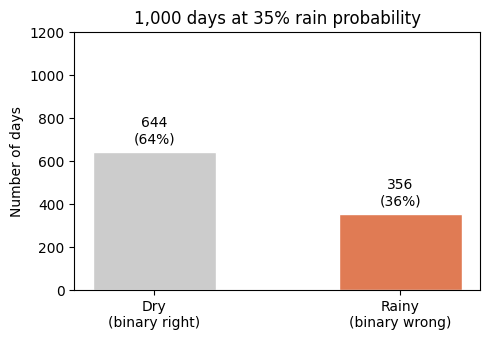

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Dry\n(binary right)', 'Rainy\n(binary wrong)'],
              [dry_low, rainy_low],
              color=['#cccccc', '#e07b54'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt=lambda v: f'{int(v):,}\n({v/n_days:.0%})', padding=4, fontsize=10)
ax.set(title=f'1,000 days at {p_rain_low:.0%} rain probability',
       ylabel='Number of days', ylim=(0, 1_200))
plt.tight_layout()
plt.show()

Rounding down still leads to meaningful errors: about **35% of the time**, it rains anyway.

The error rate follows the probability directly:
- 60% forecast → round up → wrong ~40% of the time
- 35% forecast → round down → wrong ~35% of the time

A 60% forecast and a 35% forecast *feel* completely different. But under binary thinking, both lead to substantial errors — just in opposite directions.

## 3. The cost of getting it wrong — errors aren't equal

The error rate treats every wrong prediction as equally bad. But the two types of mistake have very different costs:

- **Caught without an umbrella** (predicted dry, it rained): ruined commute, soaked bag — call it **$15**
- **Carried an umbrella for nothing** (predicted rain, it stayed dry): minor inconvenience — call it **$5**

Given those costs, what's the expected cost per day of binary thinking? And what threshold would a cost-aware decision-maker actually use?

In [ ]:
cost_wet     = 15   # cost when caught without umbrella in rain
cost_useless =  5   # cost of carrying umbrella on a dry day

probabilities = [p / 100 for p in range(5, 96, 5)]
binary_costs  = []
optimal_costs = []

# Optimal threshold: bring umbrella when expected cost of getting wet
# exceeds expected cost of carrying it needlessly.
# p × cost_wet > (1-p) × cost_useless  →  p > cost_useless / (cost_wet + cost_useless)
optimal_threshold = cost_useless / (cost_wet + cost_useless)

for p in probabilities:
    sim = RNG.binomial(1, p, 1_000)   # 1 = rained, 0 = dry

    # Binary strategy: bring umbrella only if p > 0.50
    binary_cost = (sim == 0).sum() * (-cost_useless) if p > 0.5 else (sim == 1).sum() * (-cost_wet)
    binary_costs.append(binary_cost / 1_000)

    # Cost-aware strategy: bring umbrella if p > optimal_threshold
    opt_cost = (sim == 0).sum() * (-cost_useless) if p > optimal_threshold else (sim == 1).sum() * (-cost_wet)
    optimal_costs.append(opt_cost / 1_000)

print(f"Cost-aware threshold: bring umbrella when forecast > {optimal_threshold:.0%}")
print(f"  (Derived from: p × ${cost_wet} > (1-p) × ${cost_useless})")
print(f"\nBinary thinking threshold: 50% — ignores the cost asymmetry entirely.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([p * 100 for p in probabilities], binary_costs,
        '-o', ms=5, color='#e07b54', label='Binary thinking (50% threshold)')
ax.plot([p * 100 for p in probabilities], optimal_costs,
        '-o', ms=5, color='steelblue', label=f'Cost-aware threshold ({optimal_threshold:.0%})')
ax.axhline(0, ls='-', color='lightgray', lw=0.8)
ax.axvline(optimal_threshold * 100, ls='--', color='steelblue', lw=1, alpha=0.6)
ax.axvline(50, ls='--', color='#e07b54', lw=1, alpha=0.6)
ax.fill_between([optimal_threshold * 100, 50],
                [min(binary_costs) - 0.5] * 2, [0.1] * 2,
                alpha=0.08, color='#e07b54', label='Gap: cost of ignoring asymmetry')
ax.set(title='Expected cost per day: binary thinking vs. cost-aware threshold',
       xlabel='Forecast probability (%)', ylabel='Expected cost ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The two curves diverge in the **25%–50% range**. There, binary thinking predicts "dry" and pays \\$15 whenever it rains. A cost-aware thinker brings the umbrella in that range and pays only \\$5 on dry days.

The optimal threshold isn't 50% — it's wherever expected costs balance: `p × $15 = (1-p) × $5` → `p = 25%`. Binary thinking misses this because it treats the decision as symmetric when the costs are not.

Here's what makes this interesting: **forecasters face the same cost asymmetry, but from the other side.** Getting blamed for underpredicting rain costs them more reputationally than overpredicting. So some providers deliberately inflate their probabilities — especially at the low end. Section 4 examines what that does to your umbrella decision.

## 4. The forecaster's rain bias — and whether it accidentally helps

Forecasters face the same asymmetric cost structure as users, but from the opposite side: underpredicting rain (leaving users soaked and angry) costs them more reputationally than overpredicting (users carry an unnecessary umbrella and shrug). So some forecast providers apply a **wet bias** — deliberately inflating rain probabilities, especially at the low end. A model estimate of 5% might be published as ~20%.

Simulate three strategies across all probability levels and compare their expected daily cost:
1. **Binary thinking on true probabilities** — threshold at 50%
2. **Binary thinking on wet-biased forecast** — threshold at 50%, applied to inflated numbers
3. **Cost-optimal strategy** — threshold at 25%, applied to true probabilities

In [ ]:
inflation = 0.15   # wet bias factor: true 5% → reported ~19%, true 35% → reported ~45%

probabilities       = [p / 100 for p in range(5, 96, 5)]
binary_true_costs   = []
binary_biased_costs = []
optimal_costs_s4    = []

for p in probabilities:
    sim      = RNG.binomial(1, p, 1_000)
    biased_p = min(1.0, p + inflation * (1 - p))

    # Strategy 1: binary on true probability (threshold 50%)
    c1 = (sim == 0).sum() * (-cost_useless) if p > 0.5 else (sim == 1).sum() * (-cost_wet)
    binary_true_costs.append(c1 / 1_000)

    # Strategy 2: binary on wet-biased forecast (threshold 50% applied to biased_p)
    c2 = (sim == 0).sum() * (-cost_useless) if biased_p > 0.5 else (sim == 1).sum() * (-cost_wet)
    binary_biased_costs.append(c2 / 1_000)

    # Strategy 3: cost-optimal on true probability (threshold 25%)
    c3 = (sim == 0).sum() * (-cost_useless) if p > optimal_threshold else (sim == 1).sum() * (-cost_wet)
    optimal_costs_s4.append(c3 / 1_000)

# Wet bias shifts binary thinking's effective threshold on the true-probability scale
# biased_p > 0.5  →  p + inflation*(1-p) > 0.5  →  p > (0.5 - inflation) / (1 - inflation)
biased_effective_threshold = (0.5 - inflation) / (1 - inflation)

print(f"Strategy 1 — binary on true forecast:    effective threshold = 50%")
print(f"Strategy 2 — binary on biased forecast:  effective threshold ≈ {biased_effective_threshold:.0%} (true probability)")
print(f"Strategy 3 — cost-optimal:               effective threshold = {optimal_threshold:.0%}")
print(f"\nThe wet bias closes part of the gap — but not all the way to optimal.")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([p * 100 for p in probabilities], binary_true_costs,
        '-o', ms=4, color='#e07b54',
        label='Binary on true forecast (50% threshold)')
ax.plot([p * 100 for p in probabilities], binary_biased_costs,
        '-o', ms=4, color='#c084fc',
        label=f'Binary on wet-biased forecast (~{biased_effective_threshold:.0%} effective threshold)')
ax.plot([p * 100 for p in probabilities], optimal_costs_s4,
        '-o', ms=4, color='steelblue',
        label=f'Cost-optimal ({optimal_threshold:.0%} threshold)')
ax.axhline(0, ls='-', color='lightgray', lw=0.8)
ax.axvline(optimal_threshold * 100, ls='--', color='steelblue', lw=1, alpha=0.5)
ax.axvline(biased_effective_threshold * 100, ls='--', color='#c084fc', lw=1, alpha=0.5)
ax.axvline(50, ls='--', color='#e07b54', lw=1, alpha=0.5)
ax.set(title='Expected cost per day — three strategies across all forecast probabilities',
       xlabel='True rain probability (%)', ylabel='Expected cost ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The wet bias partially closes the gap. By inflating probabilities, the forecaster shifts a binary thinker's effective threshold from 50% down to ~41% (in true-probability terms). That helps in the 41–50% range — but leaves the 25–41% zone still uncovered, where the cost-optimal strategy would bring an umbrella and both binary strategies don't.

The three-layer picture is now complete:
1. **The forecaster inflates** (wet bias) because their asymmetric costs reward overprediction.
2. **Binary thinking rounds** whatever number is seen into "yes" or "no" at 50%.
3. **Costs are asymmetric**, so the right threshold is 25% — which neither layer of distortion fully accounts for.

## 5. Takeaway

Three layers of distortion sit between a weather model and your umbrella decision:

1. **Forecasters inflate probabilities** (wet bias) because underpredicting rain costs them more than overpredicting. A true 5% estimate might be published as ~20%.

2. **Binary thinking rounds** whatever you see into "yes" or "no" at 50% — discarding the actual number entirely.

3. **Costs are asymmetric**, so the correct threshold isn't 50%. When getting soaked costs \\$15 and carrying a useless umbrella costs \\$5, the break-even is 25%. The wet bias partially compensates by shifting the effective threshold to ~41% — but doesn't close the gap to optimal.

The same pattern appears wherever probability gets communicated: a 35% chance a project slips, a 40% chance a treatment works, a 30% chance of a recession. Treating "under 50%" as "won't happen" throws away real information and leads to poor preparation for outcomes that are genuinely likely enough to plan for.

The rest of this course builds tools that keep the probability in play rather than rounding it away.